# LOAN  APPROVAL  PREDICTION  PROJECT

# 1. Project Introduction

 Loan Approval Prediction is a Machine Learning project that predicts whether a loan application is likely to be approved or rejected based on an applicant's financial and personal information

 The dataset contains features such as income, loan amount, loan term, CIBIL score, education, self-employment status, and asset values. The goal is to analyze these factors, identify important patterns, and build a machine learning model that can predict the Loan Status.

 This project helps demonstrate important Data Science skills including data cleaning, exploratory data analysis (EDA), feature engineering, data visualization, and classification modeling.

# 2. Importing Required Libraries

In [3]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Import seaborn for data visualization
import seaborn as sns

# Import LabelEncoder to convert categorical values into numerical values
from sklearn.preprocessing import LabelEncoder

# Import train_test_split to divide the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import Logistic Regression for classification
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics to measure model performance 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Print confirmation message
print("All libraries imported successfully!")

All libraries imported successfully!


# 3. Loading the Dataset

In [4]:
# Load the loan dataset into a Pandas DataFrame
df = pd.read_csv("loan_approval_dataset.csv")

# Display the dataset
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


# UNDERSTANDING THE DATASET

# 4. Checking the Number of Rows and Columns

In [5]:
# Display the number of rows and columns in the dataset
df.shape

(4269, 13)

# 5. Checking Column Name

In [6]:
# Display all column names in the dataset
df.columns.tolist()

['loan_id',
 ' no_of_dependents',
 ' education',
 ' self_employed',
 ' income_annum',
 ' loan_amount',
 ' loan_term',
 ' cibil_score',
 ' residential_assets_value',
 ' commercial_assets_value',
 ' luxury_assets_value',
 ' bank_asset_value',
 ' loan_status']

# 6. Checking Dataset Information

In [7]:
# Display information about columns, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


# 7. Checking Statistical Summary

In [8]:
# Display descriptive statistics for numerical columns
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


# 8. Checking Missing Values

In [9]:
# Checking the number of missing values in each column
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

# 9. Checking Duplicate Rows

In [10]:
# Check the number of duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

# DATA CLEANING

# 10. Removing Unnecessary Spaces from Column Names

In [13]:
# Remove extra spaces from the begining and end of column names
df.columns = df.columns.str.strip()

# Display the updated column names
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

# 11. Checking Missing Values

In [14]:
# Check the total number of missinng values ineach column
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

# 12. Checking Duplicate Records

In [15]:
# Check the total number of duplicate rows
df.duplicated().sum()

np.int64(0)

# 13. Removing Duplicate Records

In [17]:
# Remove duplicate rows from the dataset 
df = df.drop_duplicates()

# Check the shape of the dataset after removing duplicates
df.shape

(4269, 13)

# 14. Checking Unique Values in Categorical Columns 

In [18]:
# Display unique values in the education column
df["education"].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [19]:
# Display unique values in the self_employed column
df["self_employed"].unique()

array([' No', ' Yes'], dtype=object)

In [20]:
# Display the data type of each column
df.dtypes

loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

# EXPLORATORY DATA ANALYSIS (EDA)

# 15. Loan Status Distribution

 Checking the Target Variable Distribution

In [21]:
# Display the number of approved and rejected loans
df["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

# 16. Visualizing Loan Status

 Loan Approval Distribution

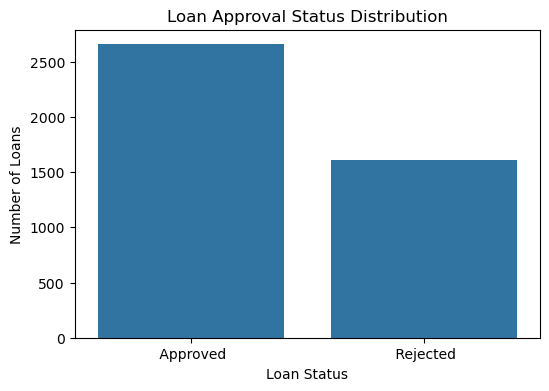

In [23]:
# Create a count plot to visualize loan approval status
plt.figure(figsize=(6,4))
sns.countplot(x="loan_status", data=df)

# Add title and axis labels
plt.title("Loan Approval Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")

# Display the chart
plt.show()

# 17. Education Distribution

 Analyzing Education Levels

In [24]:
# Display the number of applicants in each education category
df["education"].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

# 18. Visualizing education distribution

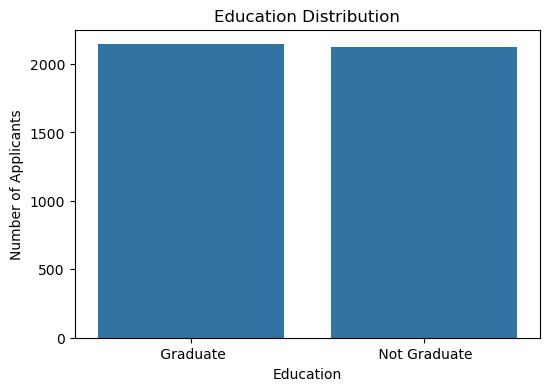

In [25]:
# Visualize the distribution of education levels
plt.figure(figsize=(6,4))
sns.countplot(x="education", data=df)

# Add title and axis labels
plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")

# Display the chart
plt.show()

# 19. Self-Employment Distribution

# Analyzing Employment Status

In [26]:
# Display the number of self-employed and non-self-employed applicants
df["self_employed"].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

# 20. Visualization of Self-Employment Distribution

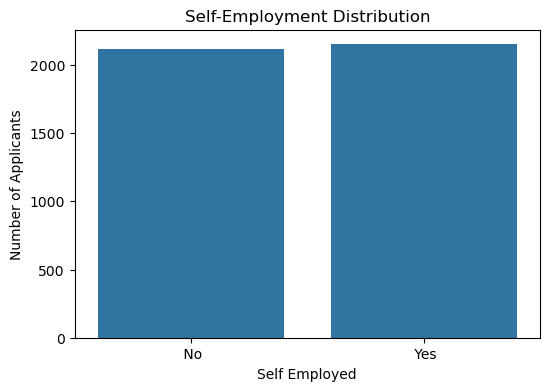

In [27]:
# Visualize the self-employment distribution
plt.figure(figsize=(6,4))
sns.countplot(x="self_employed", data=df)

# Add title and axis labels
plt.title("Self-Employment Distribution")
plt.xlabel("Self Employed")
plt.ylabel("Number of Applicants")

# Display the chart
plt.show()

# 21. Number of Dependents

 Analyzing Dependents

In [28]:
# Display the distribution of applicants based on the number of dependents
df["no_of_dependents"].value_counts().sort_index()

no_of_dependents
0    712
1    697
2    708
3    727
4    752
5    673
Name: count, dtype: int64

# 22. Visualizing the Number of Dependents

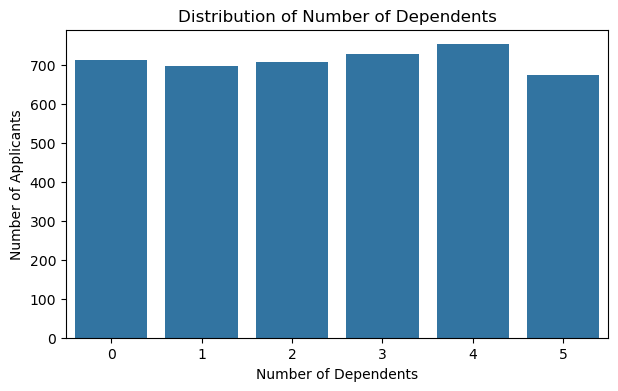

In [29]:
# Visualize the number of dependents
plt.figure(figsize=(7,4))
sns.countplot(x="no_of_dependents", data=df)

# Add title and axis labels
plt.title("Distribution of Number of Dependents")
plt.xlabel("Number of Dependents")
plt.ylabel("Number of Applicants")

# Display the chart
plt.show()

# NUMERICAL FEATURE ANALYSIS

# 23. Income Distribution

 Analyzing Annual Distribution

In [30]:
# Display basic statistics of annual income
df["income_annum"].describe()

count    4.269000e+03
mean     5.059124e+06
std      2.806840e+06
min      2.000000e+05
25%      2.700000e+06
50%      5.100000e+06
75%      7.500000e+06
max      9.900000e+06
Name: income_annum, dtype: float64

# 24. Visualization of annual income

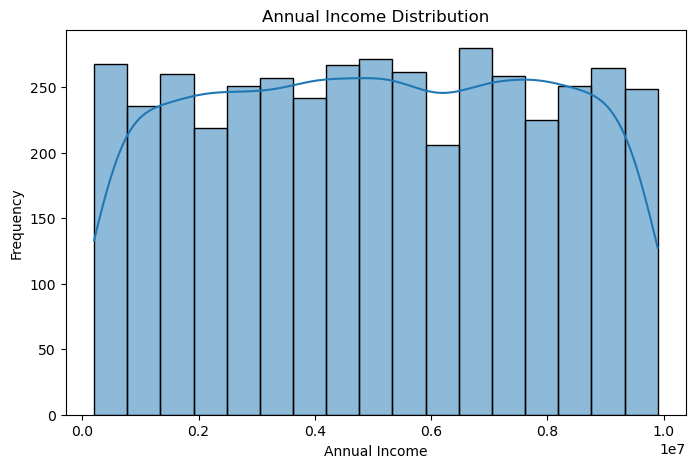

In [31]:
# Visualize the distribution of annual income
plt.figure(figsize=(8,5))
sns.histplot(df["income_annum"], kde=True)

# Add title and axis labels
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

# Display the chart
plt.show()

# 25. Loan Amount Distribution

 Analyzing Loan Amount

In [32]:
# Display basic statistics of loan amount
df["loan_amount"].describe()

count    4.269000e+03
mean     1.513345e+07
std      9.043363e+06
min      3.000000e+05
25%      7.700000e+06
50%      1.450000e+07
75%      2.150000e+07
max      3.950000e+07
Name: loan_amount, dtype: float64

# 26. Visualization of the loan amount

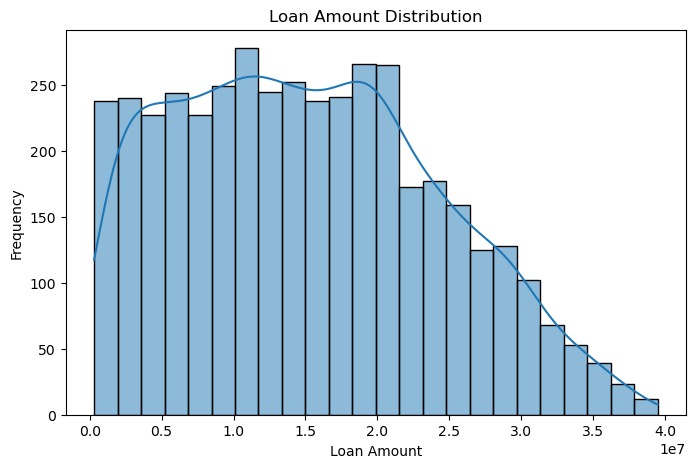

In [33]:
# Visualize the distribution of loan amount
plt.figure(figsize=(8,5))
sns.histplot(df["loan_amount"], kde=True)

# Add title and axis labels
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

# Display the chart
plt.show()

# 27. CIBIL Score Distribution

 Analyzing Credit Score

In [34]:
# Display basic statistics of CIBIL score
df["cibil_score"].describe()

count    4269.000000
mean      599.936051
std       172.430401
min       300.000000
25%       453.000000
50%       600.000000
75%       748.000000
max       900.000000
Name: cibil_score, dtype: float64

# 28. Visualization of CIBIL Scores

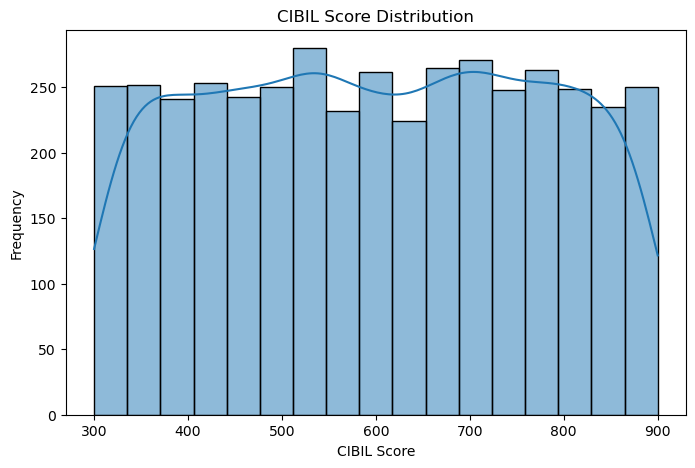

In [35]:
# Visualize the distribution of CIBIL scores
plt.figure(figsize=(8,5))
sns.histplot(df["cibil_score"], kde=True)

# Add title and axis labels
plt.title("CIBIL Score Distribution")
plt.xlabel("CIBIL Score")
plt.ylabel("Frequency")

# Display the chart
plt.show()

# 29. Loan Term Distribution

 Analyzing Loan Repayment Period

In [36]:
# Display the distribution of loan terms
df["loan_term"].value_counts().sort_index()

loan_term
2     404
4     447
6     490
8     386
10    436
12    456
14    405
16    412
18    422
20    411
Name: count, dtype: int64

# 30. Visualization of Loan Term

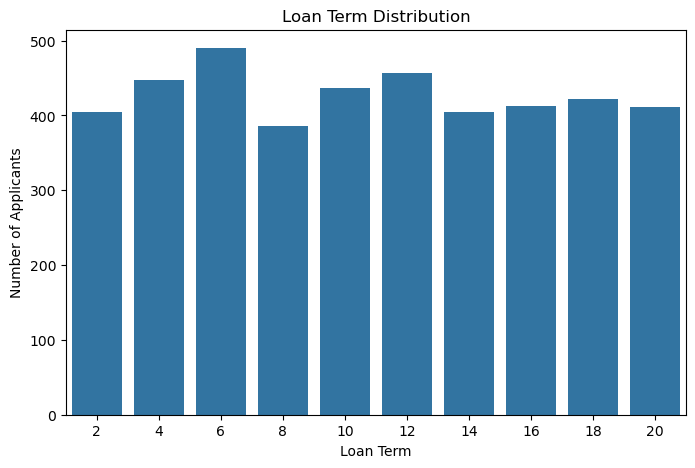

In [37]:
# Visualize the distribution of loan terms
plt.figure(figsize=(8,5))
sns.countplot(x="loan_term", data=df)

# Add title and axis labels
plt.title("Loan Term Distribution")
plt.xlabel("Loan Term")
plt.ylabel("Number of Applicants")

# Display the chart
plt.show()

# 31. Asset Value Analysis

 Analyzing Different Asset Categories

In [40]:
# Display summary statistics for different asset values
df[["residential_assets_value",
    "commercial_assets_value",
    "bank_asset_value"]].describe()

,residential_assets_value,commercial_assets_value,bank_asset_value
count,4.269000e+03,4.269000e+03,4.269000e+03
mean,7.472617e+06,4.973155e+06,4.976692e+06
std,6.503637e+06,4.388966e+06,3.250185e+06
min,-1.000000e+05,0.000000e+00,0.000000e+00
25%,2.200000e+06,1.300000e+06,2.300000e+06
50%,5.600000e+06,3.700000e+06,4.600000e+06
75%,1.130000e+07,7.600000e+06,7.100000e+06
max,2.910000e+07,1.940000e+07,1.470000e+07


 Comparing Asset Values

In [43]:
# Calculate the average value value of each asset category
asset_means = df[["residential_assets_value",
                  "commercial_assets_value",
                  "luxury_assets_value",
                  "bank_asset_value"]].mean()

# Display the average asset values
asset_means

residential_assets_value    7.472617e+06
commercial_assets_value     4.973155e+06
luxury_assets_value         1.512631e+07
bank_asset_value            4.976692e+06
dtype: float64

# 32. Visualization of asset value analysis

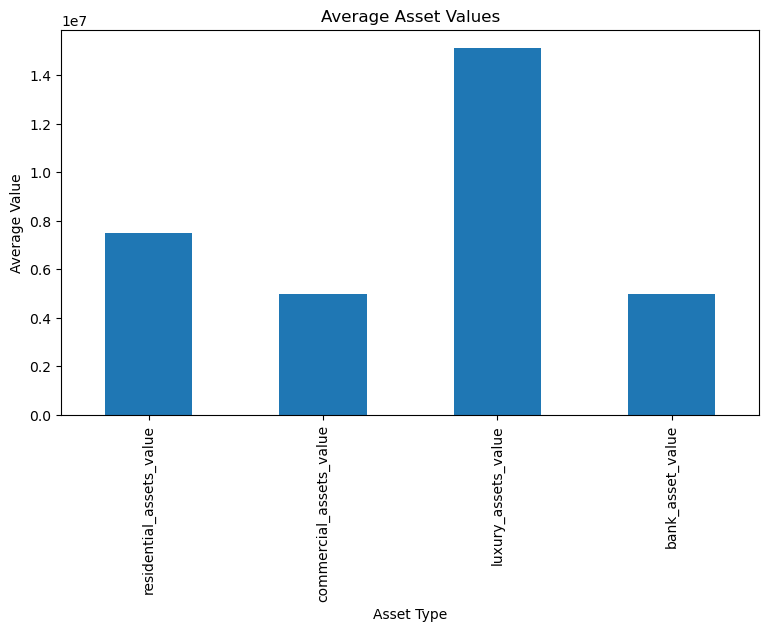

In [44]:
# Visualize the average value of different asset categories
plt.figure(figsize=(9,5))
asset_means.plot(kind="bar")

# Add title and axis labels
plt.title("Average Asset Values")
plt.xlabel("Asset Type")
plt.ylabel("Average Value")

# Display the chart
plt.show()

# LOAN STATUS VS IMPORTANT FEATURES

# 33. CIBIL Score vs Loan Status

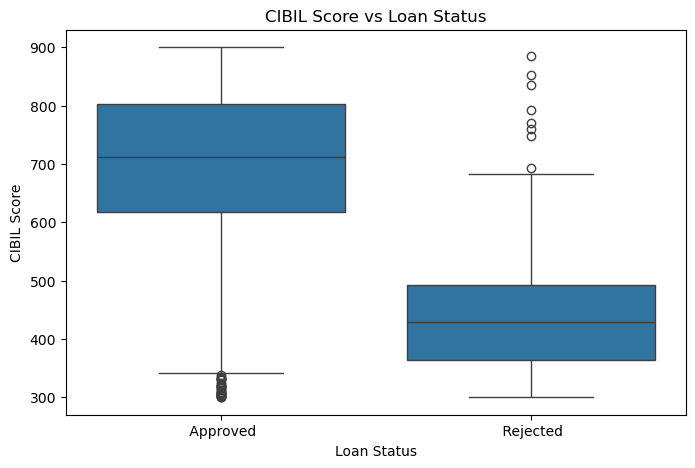

In [45]:
# visualize the relationship between CIBIL score and loan status
plt.figure(figsize=(8,5))
sns.boxplot(x="loan_status", y="cibil_score", data=df)

# Add title and axis label
plt.title("CIBIL Score vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("CIBIL Score")

# Display the chart
plt.show()

# 34. Annual Income vs Loan Status

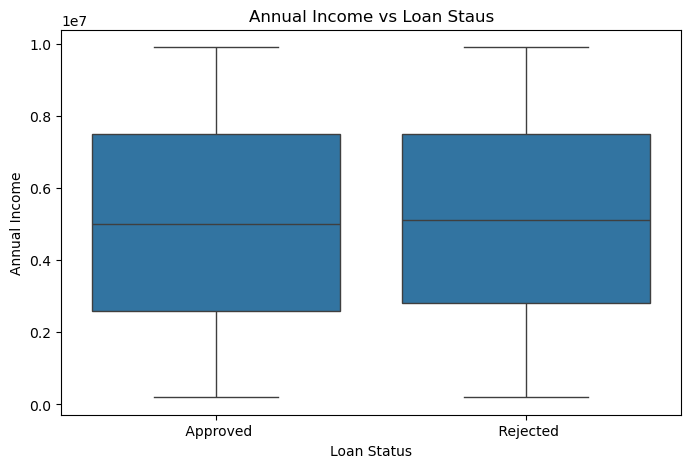

In [46]:
# visualize the relationship between annual income and loan status
plt.figure(figsize=(8,5))
sns.boxplot(x="loan_status", y="income_annum", data=df)

# Add title and axis labels
plt.title("Annual Income vs Loan Staus")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")

# Display the chart
plt.show()

# 35. Loan Amount vs Loan Status

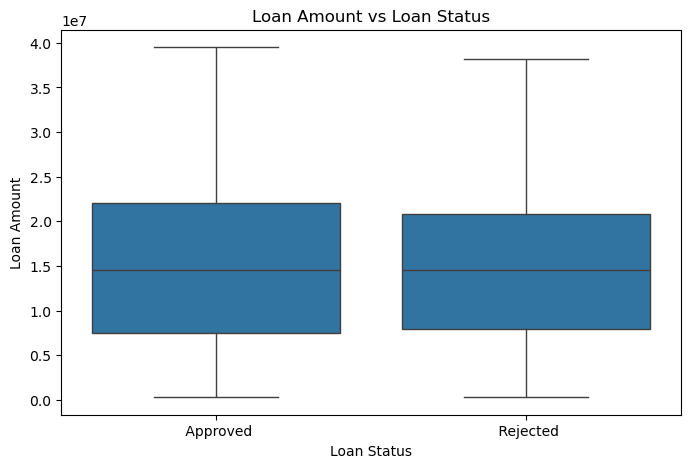

In [47]:
# Visualize the relationship between loan amount and loan status
plt.figure(figsize=(8,5))
sns.boxplot(x="loan_status", y="loan_amount", data=df)

# Add title and axis labels
plt.title("Loan Amount vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")

# Display the chart
plt.show()

# 36. Education vs Loan Status

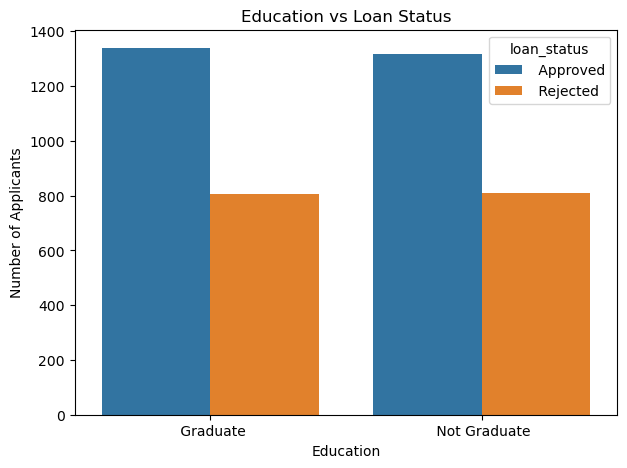

In [48]:
# Visualize the relationship between education and loan status
plt.figure(figsize=(7,5))
sns.countplot(x="education", hue="loan_status", data=df)

# Add title and axis labels
plt.title ("Education vs Loan Status")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")

# Display the chart

plt.show()

# 37. Self-Employment vs Loan Status

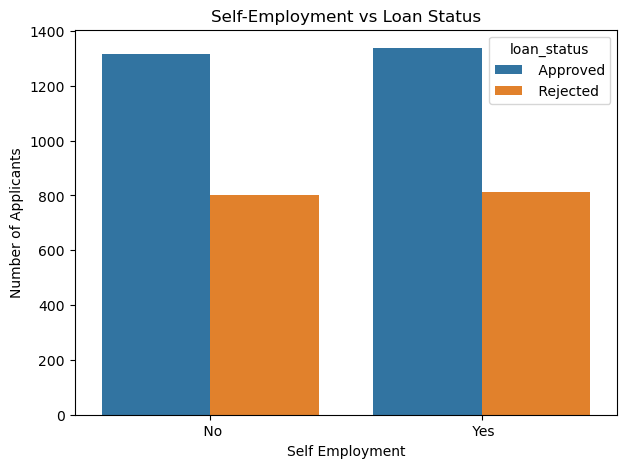

In [50]:
# Visualize the relationship between self-employment and loan status
plt.figure(figsize=(7,5))
sns.countplot(x="self_employed", hue="loan_status", data=df)

# Add title and axis labels
plt.title("Self-Employment vs Loan Status")
plt.xlabel("Self Employment")
plt.ylabel("Number of Applicants")

# Display the chart
plt.show()

# CORREALATION ANALYSIS

# 38. Understanding Relationships Between Numerical Features

In [52]:
# Select numerical columns for correlation analysis
numeric_columns = ["no_of_dependents",
                   "income_annum",
                   "loan_amount",
                   "cibil_score",
                   "residential_assets_value",
                   "commercial_assets_value",
                   "luxury_assets_value",
                   "bank_asset_value"]

# Calculate the correlation matrix 
correlation_matrix = df[numeric_columns].corr()

# Display the correlation matrix
correlation_matrix

,no_of_dependents,income_annum,loan_amount,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
no_of_dependents,1.000000,0.007266,-0.003366,-0.009998,0.007376,-0.001531,0.002817,0.011163
income_annum,0.007266,1.000000,0.927470,-0.023034,0.636841,0.640328,0.929145,0.851093
loan_amount,-0.003366,0.927470,1.000000,-0.017035,0.594596,0.603188,0.860914,0.788122
cibil_score,-0.009998,-0.023034,-0.017035,1.000000,-0.019947,-0.003769,-0.028618,-0.015478
residential_assets_value,0.007376,0.636841,0.594596,-0.019947,1.000000,0.414786,0.590932,0.527418
commercial_assets_value,-0.001531,0.640328,0.603188,-0.003769,0.414786,1.000000,0.591128,0.548576
luxury_assets_value,0.002817,0.929145,0.860914,-0.028618,0.590932,0.591128,1.000000,0.788517
bank_asset_value,0.011163,0.851093,0.788122,-0.015478,0.527418,0.548576,0.788517,1.000000


# 39. Correlation Heatmap

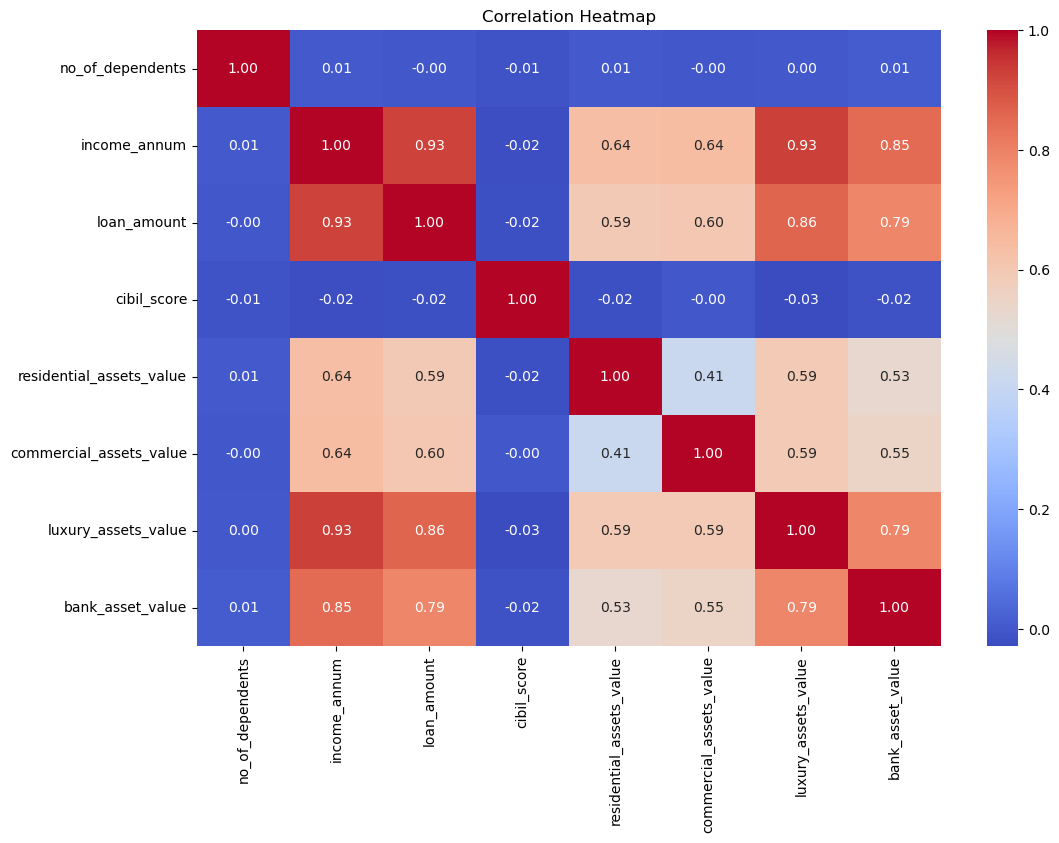

In [55]:
# Create a heatmap to visualize correlations between numerical features
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

# Add title 
plt.title("Correlation Heatmap")

# Display the chart
plt.show()

# FEATURE ENGINEERING & DATA PREPROCESSING

# 40. Checking Categorical Values 

In [57]:
# Display the unique vales of categorical columns

print("Education:", df["education"].unique())
print("Self Employed:", df["self_employed"].unique())
print("Loan Status:", df["loan_status"].unique())

Education: [' Graduate' ' Not Graduate']
Self Employed: [' No' ' Yes']
Loan Status: [' Approved' ' Rejected']


# 41. Encoding Categorical Columns (Converting Text Values into Numerical Values)

In [59]:
# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Convert education values into numerical values
df["education"] = label_encoder.fit_transform(df["education"])

# Convert self-employed values into numerical values into numerical values
df["self_employed"] = label_encoder.fit_transform(df["self_employed"])

# Convert loan status values into numerical values
df["loan_status"] = label_encoder.fit_transform(df["loan_status"])

# Display the first rows after encoding
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


# 42. Checking the Encoded Data

In [60]:
# Display the unique numerical values after encoding

print("Education:", df["education"].unique())
print("Self Employed:", df["self_employed"].unique())
print("Loan Status:", df["loan_status"].unique())

Education: [0 1]
Self Employed: [0 1]
Loan Status: [0 1]


# 43. Create Features and Target (Separating Independent and Dependent Variables)

In [61]:
# Define the indepent features
x = df.drop("loan_status", axis=1)

# Define the target varible
y = df["loan_status"]

# Display the shape of features and target
print("Feature shape:", x.shape)
print("Target shape:", y.shape)

Feature shape: (4269, 12)
Target shape: (4269,)


# 44. Removing Loan ID 

In [62]:
# Remove loan_id because it is only an identifier
x = x.drop("loan_id", axis=1)

# Display the remaining feature columns
x.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='object')

# 45. Splitting the Dataset into Training and Testing

In [63]:
# Split the dataset into traininh and testing sets
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.20, random_state=42, stratify=y)

# Display the shape of training and testing data
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (3415, 11)
x_test shape: (854, 11)
y_train shape: (3415,)
y_test shape: (854,)


# MODEL BUILDING

# 46 Logistic Regression Model (Training the Logistic Regression Model)

In [64]:
# Create a Logistic Regression model 
logistic_model = LogisticRegression(max_iter=1000)

# Train the model using the training data
logistic_model.fit(x_train, y_train)

# Display a confirmation message
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


# 47. Making Predictions (Predicting Loan Approval Status)

In [65]:
# Make predictions on the test dataset
y_pred = logistic_model.predict(x_test)

# Display the first 10 predictions
y_pred[:10]

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

# MODEL EVALUATION

# 48. Accuracy Score (Checking Model Accuracy)

In [66]:
# Calculate the accuracy of the Logistic Regression model
accuracy = accuracy_score(y_test, y_pred)

# Display the accuracy 
print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.8079625292740047


# CONFUSION MATRIX

# 49. Visualizing Prediction Results

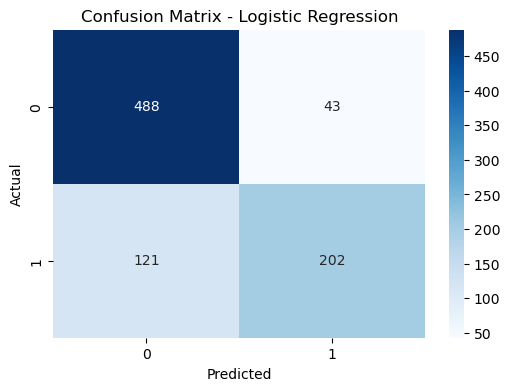

In [67]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")


# Add title and axis labels 
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Display the chart
plt.show()

# CLASSIFICATION REPORT

# 50. Evaluating Precision, Recall and F1-Score

In [68]:
# Generate the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86       531
           1       0.82      0.63      0.71       323

    accuracy                           0.81       854
   macro avg       0.81      0.77      0.78       854
weighted avg       0.81      0.81      0.80       854



# 51. Acual vs Predicted Values

In [69]:
# Create a DataFrame to compare actual and predicted values
comparison = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})

# Display the first 10 comparisons 
comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,1,0
4,0,0
5,1,1
6,1,0
7,0,0
8,0,0
9,0,0


# RANDOM FOREST CLASSIFIER

# 52. Importing Random Forest

In [71]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# print message confirmation
print("Library is imported successfully!")

Library is imported successfully!


# 53. Creating the Random Forest Model

In [72]:
# Create a Random Forest Classifier
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Display the model
random_forest_model

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 54. Training the Model on Loan Data

In [73]:
# Train the Random Forest model using the Training dataset
random_forest_model.fit(x_train, y_train)

# Display a confirmation message
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


# 56. Making Predictions (Prediction Loan Approval Status)

In [74]:
# Make predictions using the Random Forest model
rf_pred = random_forest_model.predict(x_test)

# Display the first 10 predictions 
rf_pred[:10]

array([0, 0, 0, 1, 0, 1, 1, 0, 0, 0])

# RANDOM FOREST MODEL EVALUATION

# 57. Accuracy Score (Checking Random Forest Accuracy)

In [75]:
# Calculate the accuracy of the Random Forest model
rf_accuracy = accuracy_score(y_test, rf_pred)

# Display the accuracy
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9836065573770492


# CONFUSION MATRIX

# 58. Visualizing Random Forest Predictions

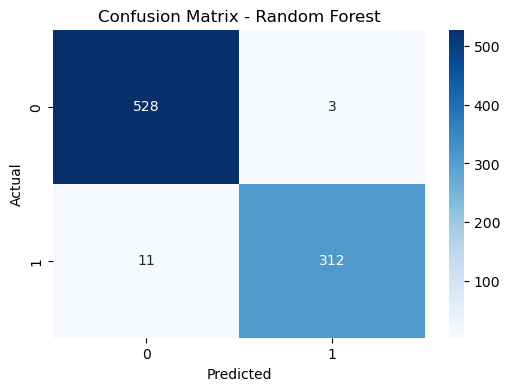

In [76]:
# Calculate the confusion matrix for Random Forest
rf_cm = confusion_matrix(y_test, rf_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues")

# Add title and axis labels
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Display the chart
plt.show()

# CLASSIFICATION REPORT

# 59. Evaluating Random Forest Performance

In [77]:
# Generate the classification report for Random Forest
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.99      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



# MODEL COMPARISON

# 60. Logistic Regression vs Random Forest

In [80]:
# Create a DataFrame to compare model accuracy
model_comparison = pd.DataFrame({"Model":["Logistic Regression", "Random Forest"], "Accuracy ": [accuracy, rf_accuracy]})

# Display the model comparison
model_comparison

,Model,Accuracy
0,Logistic Regression,0.807963
1,Random Forest,0.983607


# 61. Visualizing Model Accuracy

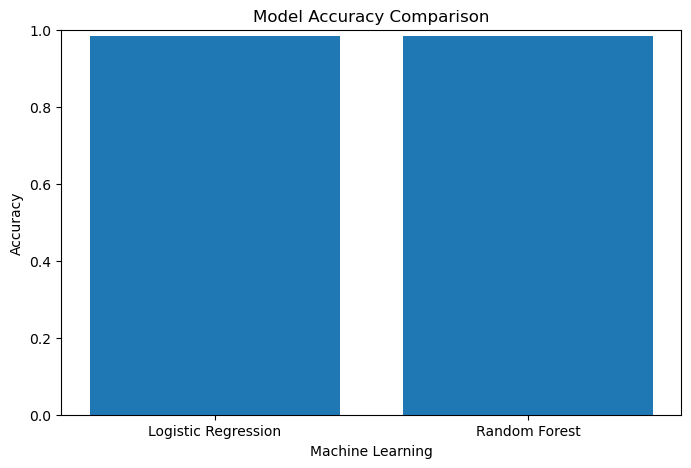

In [86]:
# Create a bar chart to compare model accuracy
models = ["Logistic Regression", "Random Forest"]
accuracies = [accuracy, rf_accuracy]

plt.figure(figsize=(8,5))
plt.bar(models, rf_accuracy)

# Add title and axis labels
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning")
plt.ylabel("Accuracy")

# Display the chart
plt.ylim(0,1)
plt.show()

# FEATURE IMPORTANCE

# 62. Identifying Important Features for Loan Approval

In [87]:
# Get the importance of each feature from the Random Forest model
feature_importance = random_forest_model.feature_importances_

# Create a DataFrame containing feature names and their importance scores
importance_df = pd.DataFrame({"Feature": x.columns, "Importance": feature_importance})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Display the feature impotance table
importance_df

,Feature,Importance
6,cibil_score,0.801152
5,loan_term,0.064358
4,loan_amount,0.030672
3,income_annum,0.020317
9,luxury_assets_value,0.019399
8,commercial_assets_value,0.018403
7,residential_assets_value,0.017593
10,bank_asset_value,0.015068
0,no_of_dependents,0.007783
2,self_employed,0.002866


#  63. Visualizing Feature Importance

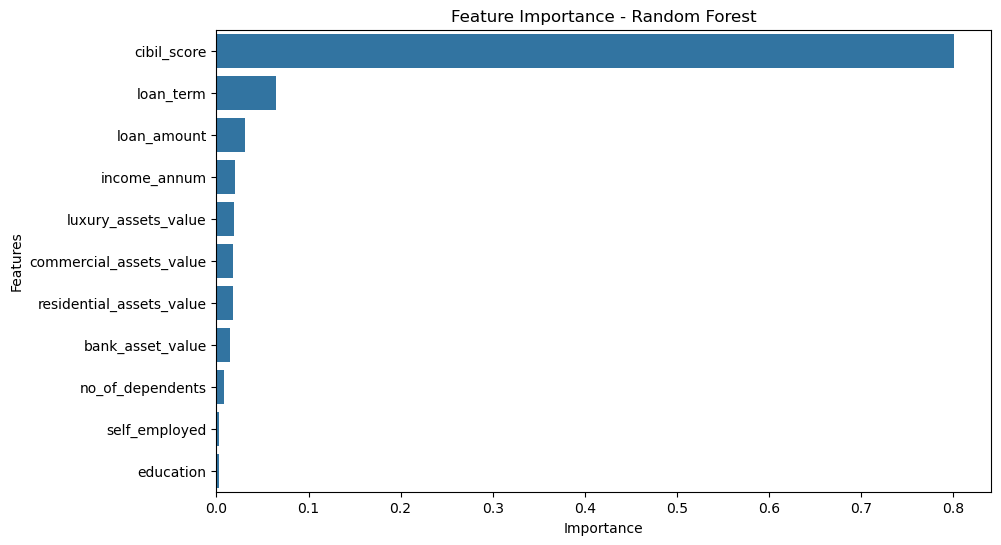

In [88]:
# Create a bar chart to visualize feature importance
plt.figure(figsize=(10,6))

sns.barplot(x="Importance", y="Feature", data=importance_df)

#  Add title and axis labels
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")

# Display the chart
plt.show()

# 64. Identifying the Most Influential Feature

In [89]:
#  Select the top 5 most important features
top_features = importance_df.head(5)

# Display the top 5 features
top_features

,Feature,Importance
6,cibil_score,0.801152
5,loan_term,0.064358
4,loan_amount,0.030672
3,income_annum,0.020317
9,luxury_assets_value,0.019399


# FINAL MODEL SELECTION

# 65. Selecting the Best Model (Comparing Model Performance)

In [90]:
# Compare the accuracy of both models
if rf_accuracy > accuracy:
   best_model = random_forest_model
   best_model_name = "Random Forest"
   best_accuracy = rf_accuracy
else:
    best_model = logistic_model
    best_model_name = "Logistic Regression"
    best_accuracy = accuracy

# Display the best-performing model
print("best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

best Model: Random Forest
Best Accuracy: 0.9836065573770492


# LOAN APPROVAL PREDICTION

# 66. Making Predictions with the Best Model

In [91]:
# Make predictions using the best-performing model
final_predictions = best_model.predict(x_test)

# Display the first 10 predictions
final_predictions[:10]

array([0, 0, 0, 1, 0, 1, 1, 0, 0, 0])

# 67. Displaying Approved or Rejected Status

In [92]:
# Convert numerical predictions back into readable loan status labels
prediction_labels = np.where(final_predictions ==1, "Approved", "Rejected")

# Display the first 10 loan predictions
prediction_labels[:10]

array(['Rejected', 'Rejected', 'Rejected', 'Approved', 'Rejected',
       'Approved', 'Approved', 'Rejected', 'Rejected', 'Rejected'],
      dtype='<U8')

# 68. Comparing Actual and Predicted Loan Status

In [93]:
# Create a DataFrame conntaining actual and predictedd loan status
prediction_summary = pd.DataFrame({"Actual_Status":np.where(y_test.values == 1,"Approved", "Rejected"),
                                   "Predicted_Status": prediction_labels})

# Display the first 10 predictions
prediction_summary.head(10)

,Actual_Status,Predicted_Status
0,Rejected,Rejected
1,Rejected,Rejected
2,Rejected,Rejected
3,Approved,Approved
4,Rejected,Rejected
5,Approved,Approved
6,Approved,Approved
7,Rejected,Rejected
8,Rejected,Rejected
9,Rejected,Rejected


# 69. Checking Final Accuracy

In [94]:
# Calculate the final accuracy of the selected model
final_accuracy = accuracy_score(y_test, final_predictions)

# Display the final model accuracy
print("Final Model:", best_model_name)
print("Final Accuracy:", final_accuracy)

Final Model: Random Forest
Final Accuracy: 0.9836065573770492


# 70. Summary of Loan Approval Prediction

In [95]:
# Display the final project summary

print("Loan Approval Prediction Project")
print("The project successfully predicts loan approval based on applicant information.")
print(f"The best performing model is{best_model_name}.")
print(f"The final model achieved an accuracy of{final_accuracy:.2%}.")
print("Random Forest provided better performance than Logistic Regression.")
print("CIBIL score, income, loan amount, and asset-related features")
print("Were among the important factors considered by the model.")

Loan Approval Prediction Project
The project successfully predicts loan approval based on applicant information.
The best performing model isRandom Forest.
The final model achieved an accuracy of98.36%.
Random Forest provided better performance than Logistic Regression.
CIBIL score, income, loan amount, and asset-related features
Were among the important factors considered by the model.


# 71. Project Conclusion

 This Loan Approval Prediction project demonstrates how Machine Learning can be used to predict loan approval based on financial and applicant-related information. The dataset was cleaned, explored, visalized, and prepared for machine learning

 Two classification models, Logistic Regression and Random Forest, were trained and evaluated. Based on the  results, Random Forest performed better and achieved the highest accuracy.

 The project provides practical experience in Data Cleaning, EDA, Data Visualization, Feature Engineering, Classification, Model Evaluation, and Feature Importance.